In [9]:
# Load required libraries
library(tidyverse)
library(corrplot)
library(ggpubr)
library(tidyverse)
library(readxl)
library(DESeq2)
library(dplyr)
library(ggplot2)
library(gridExtra)
library(ggrepel)
library(ComplexHeatmap)
library(tidyr)
library(dplyr)
library(GGally)
library(data.table) 
library(survival)


In [10]:
install.packages("survminer")


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [11]:
library(survminer)

In [12]:
base_dir = '/scratch/mjehangir/manuscript_figures/manuscript_data/'

setwd(base_dir)

In [13]:


survival_df = read.csv(file = "survival_data", header = TRUE, sep = "\t")
survival_df <- survival_df %>%
  filter(Patient_ID != "6298B")
head(survival_df, n = 22)

,Patient_ID,status,time_days,teleomere_group
,<chr>,<int>,<int>,<chr>
1,2436A,1,4629,normal
2,3188,1,1349,short
3,3988,1,1536,normal
4,6265D,1,950,normal
5,6266D,1,1195,normal
6,6269C,0,2300,short
7,6277A,NA,NA,normal
8,6285B,0,2337,short
9,6314E,0,106,normal


In [7]:
names(survival_df)[names(survival_df) == "teleomere_group"] <- "telomere_group"
survival_df$telomere_group <- trimws(survival_df$telomere_group)


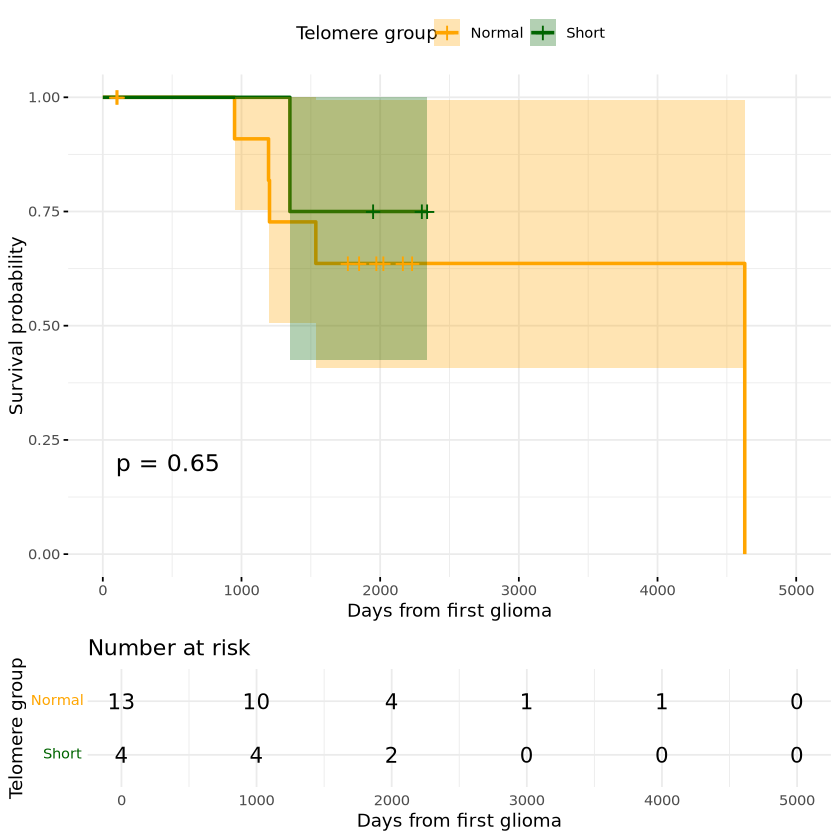

In [8]:
library(survival)
library(survminer)

surv_obj <- with(survival_df, Surv(time = time_days, event = status))
km_fit <- survfit(surv_obj ~ telomere_group, data = survival_df)

ggsurvplot(km_fit,
           data = survival_df,
           risk.table = TRUE,
           pval = TRUE,
           conf.int = TRUE,
           xlab = "Days from first glioma",
           ylab = "Survival probability",
           legend.title = "Telomere group",
           legend.labs = c("Normal", "Short"),
           palette = c("orange", "darkgreen"),
           ggtheme = theme_minimal())


In [83]:
str(survival_df)


'data.frame':	20 obs. of  4 variables:
 $ Patient_ID    : chr  "2436A" "3188" "3988" "6265D" ...
 $ status        : int  1 1 1 1 1 0 NA 0 0 0 ...
 $ time_days     : int  4629 1349 1536 950 1195 2300 NA 2337 106 2230 ...
 $ telomere_group: chr  "normal" "short" "normal" "normal" ...


In [84]:
sv_summary = read.csv(file = "sv_summary_rate_prop_pq.tsv", header = TRUE, sep = "\t")
head(sv_summary)

,type,chr,Sample_ID,arm,arm_size,sv_count,sv_size_sum,chr_length_mb,sv_rate,sv_proportion,chr_arm
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,DEL,chr1,2436A,p,124048267,581,0.201164,124.0483,4.683661,0.001621659,chr1p
2,DEL,chr1,2436A,q,124339061,551,0.173200,124.3391,4.431431,0.001392965,chr1q
3,DEL,chr1,3188,p,124048267,330,389.636135,124.0483,2.660255,3.141004259,chr1p
4,DEL,chr1,3188,q,124339061,378,82.339694,124.3391,3.040074,0.662219043,chr1q
5,DEL,chr1,3988,p,124048267,523,0.256730,124.0483,4.216101,0.002069598,chr1p
6,DEL,chr1,3988,q,124339061,459,0.194912,124.3391,3.691519,0.001567585,chr1q


In [85]:
survival_df$Sample_ID <- survival_df$Patient_ID


In [86]:
survival_df <- survival_df[complete.cases(survival_df[, c("status", "time_days")]), ]


In [87]:
library(dplyr)

sv_counts <- sv_summary %>%
  group_by(Sample_ID, type) %>%
  summarise(total_sv_count = sum(sv_count), .groups = "drop") %>%
  tidyr::pivot_wider(names_from = type, values_from = total_sv_count, values_fill = 0)
head(sv_counts)

Sample_ID,DEL,DUP,INS,INV
<chr>,<int>,<int>,<int>,<int>
2436A,16084,16,14371,20
3188,11280,113,8962,480
3988,13739,37,15833,80
6265D,12424,74,9639,147
6266D,16703,13,14780,31
6269C,12487,84,10243,1235


In [88]:
merged_df <- left_join(survival_df, sv_counts, by = "Sample_ID")


In [89]:
# Define high vs low based on median DEL count
median_DEL <- median(merged_df$DEL, na.rm = TRUE)
merged_df$DEL_group <- ifelse(merged_df$DEL > median_DEL, "High DEL", "Low DEL")


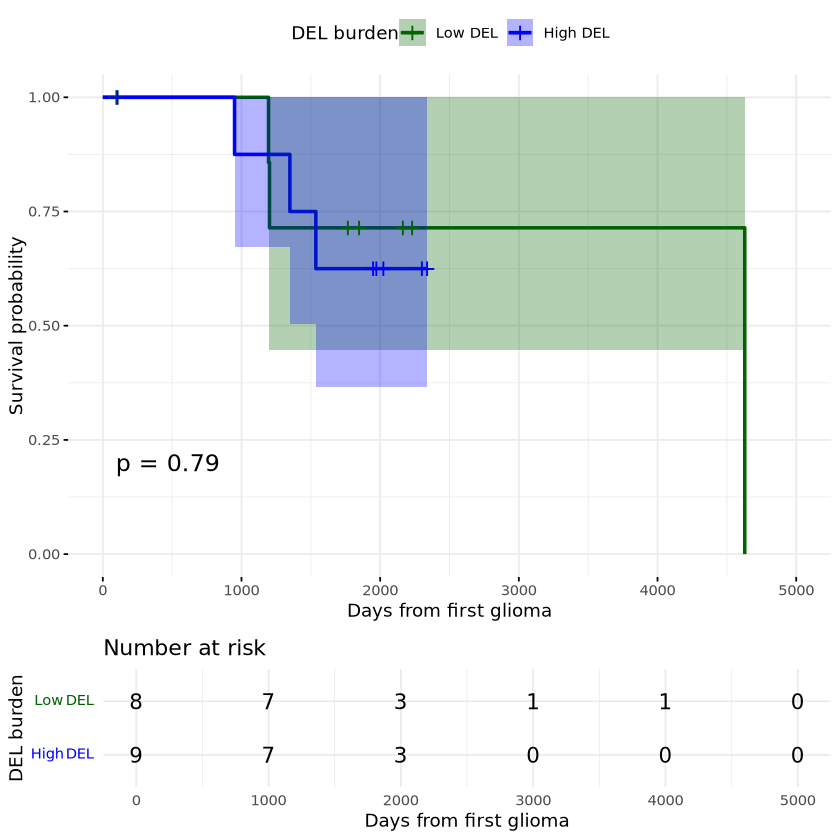

In [90]:
library(survival)
library(survminer)

surv_obj <- with(merged_df, Surv(time_days, status))
km_fit <- survfit(surv_obj ~ DEL_group, data = merged_df)

ggsurvplot(km_fit,
           data = merged_df,
           risk.table = TRUE,
           pval = TRUE,
           conf.int = TRUE,
           xlab = "Days from first glioma",
           ylab = "Survival probability",
           legend.title = "DEL burden",
           legend.labs = c("Low DEL", "High DEL"),
           palette = c("darkgreen", "blue"),
           ggtheme = theme_minimal())


In [91]:
# Define high vs low based on median DEL count
median_INV <- median(merged_df$INV, na.rm = TRUE)
merged_df$INV_group <- ifelse(merged_df$INV > median_INV, "High INV", "Low INV")


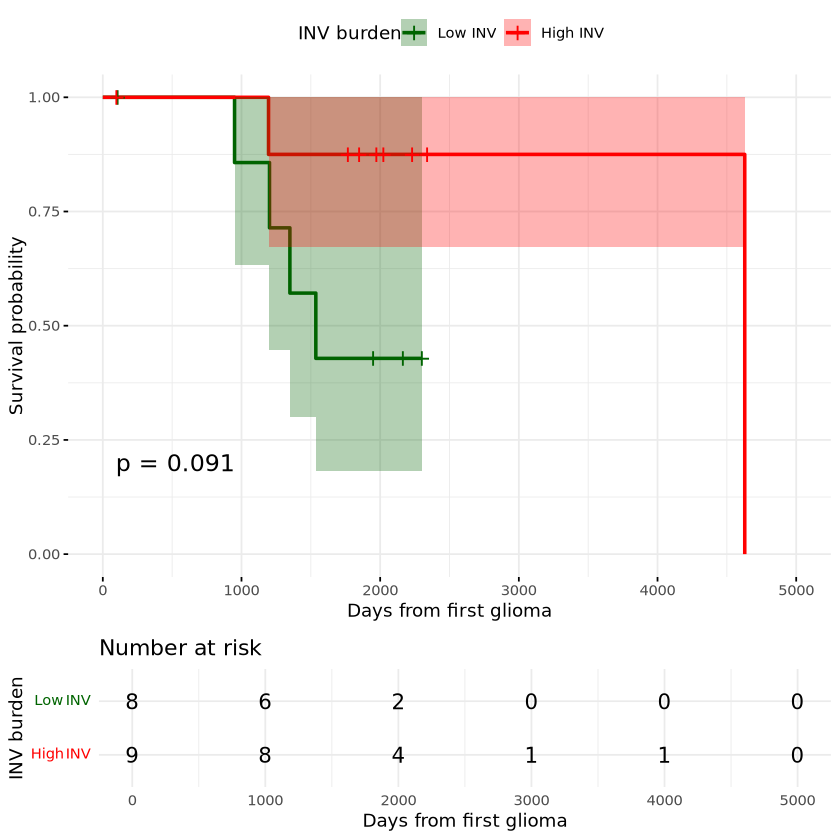

In [92]:
library(survival)
library(survminer)

surv_obj <- with(merged_df, Surv(time_days, status))
km_fit <- survfit(surv_obj ~ INV_group, data = merged_df)

ggsurvplot(km_fit,
           data = merged_df,
           risk.table = TRUE,
           pval = TRUE,
           conf.int = TRUE,
           xlab = "Days from first glioma",
           ylab = "Survival probability",
           legend.title = "INV burden",
           legend.labs = c("Low INV", "High INV"),
           palette = c("darkgreen", "red"),
           ggtheme = theme_minimal())


In [93]:
median_DUP <- median(merged_df$DUP, na.rm = TRUE)
merged_df$DUP_group <- ifelse(merged_df$DUP > median_DUP, "High DUP", "Low DUP")


In [1]:
library(survival)
library(survminer)

surv_obj <- with(merged_df, Surv(time_days, status))
km_fit <- survfit(surv_obj ~ DUP_group, data = merged_df)

ggsurvplot(km_fit,
           data = merged_df,
           risk.table = TRUE,
           pval = TRUE,
           conf.int = TRUE,
           xlab = "Days from first glioma",
           ylab = "Survival probability",
           legend.title = "DUP burden",
           legend.labs = c("DUP INV", "High DUP"),
           palette = c("orange", "red"),
           ggtheme = theme_minimal())


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




ERROR: Error: object 'merged_df' not found


In [95]:
# Define high vs low based on median DEL count
median_INS <- median(merged_df$INS, na.rm = TRUE)
merged_df$INS_group <- ifelse(merged_df$INS > median_INS, "High INS", "Low INS")


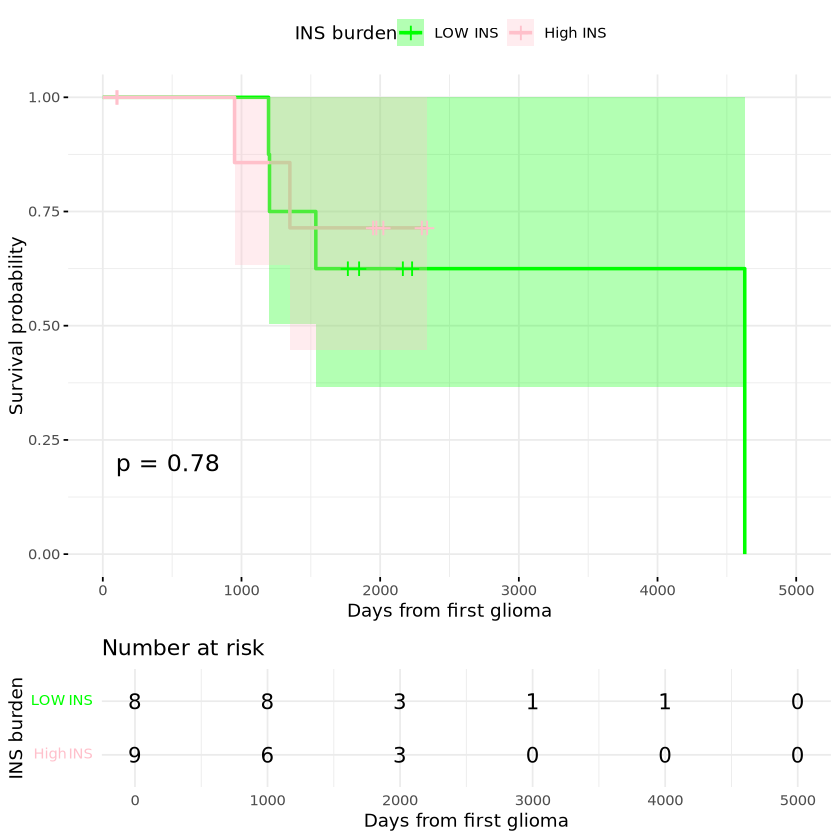

In [96]:
library(survival)
library(survminer)

surv_obj <- with(merged_df, Surv(time_days, status))
km_fit <- survfit(surv_obj ~ INS_group, data = merged_df)

ggsurvplot(km_fit,
           data = merged_df,
           risk.table = TRUE,
           pval = TRUE,
           conf.int = TRUE,
           xlab = "Days from first glioma",
           ylab = "Survival probability",
           legend.title = "INS burden",
           legend.labs = c("LOW INS", "High INS"),
           palette = c("green", "pink"),
           ggtheme = theme_minimal())


In [97]:
# Initialize a new data frame
sv_clusters <- sv_counts %>% select(Sample_ID)

# Function to cluster and assign high/low per SV type
assign_sv_group <- function(data, sv_type) {
  values <- data[[sv_type]]
  names(values) <- data$Sample_ID
  # Hierarchical clustering
  hc <- hclust(dist(values), method = "ward.D2")
  clusters <- cutree(hc, k = 2)
  df <- data.frame(Sample_ID = names(clusters), cluster = clusters)
  
  # Determine which cluster has higher SV count
  df <- df %>%
    left_join(data[, c("Sample_ID", sv_type)], by = "Sample_ID") %>%
    group_by(cluster) %>%
    summarise(mean_sv = mean(.data[[sv_type]]), .groups = "drop") %>%
    arrange(desc(mean_sv)) %>%
    mutate(group = c("High", "Low")) %>%
    select(cluster, group) %>%
    right_join(data.frame(Sample_ID = names(clusters), cluster = clusters), by = "cluster") %>%
    select(Sample_ID, group)
  
  colnames(df)[2] <- paste0(sv_type, "_group")
  return(df)
}

# Apply for each SV type
del_group <- assign_sv_group(sv_counts, "DEL")
dup_group <- assign_sv_group(sv_counts, "DUP")
inv_group <- assign_sv_group(sv_counts, "INV")

# Merge group labels
sv_clusters <- sv_clusters %>%
  left_join(del_group, by = "Sample_ID") %>%
  left_join(dup_group, by = "Sample_ID") %>%
  left_join(inv_group, by = "Sample_ID")


In [98]:
head(sv_clusters)

Sample_ID,DEL_group,DUP_group,INV_group
<chr>,<chr>,<chr>,<chr>
2436A,High,Low,Low
3188,Low,High,Low
3988,Low,Low,Low
6265D,Low,High,Low
6266D,High,Low,Low
6269C,Low,High,High


In [99]:
survival_df$Sample_ID <- survival_df$Patient_ID
merged <- left_join(survival_df, sv_clusters, by = "Sample_ID")


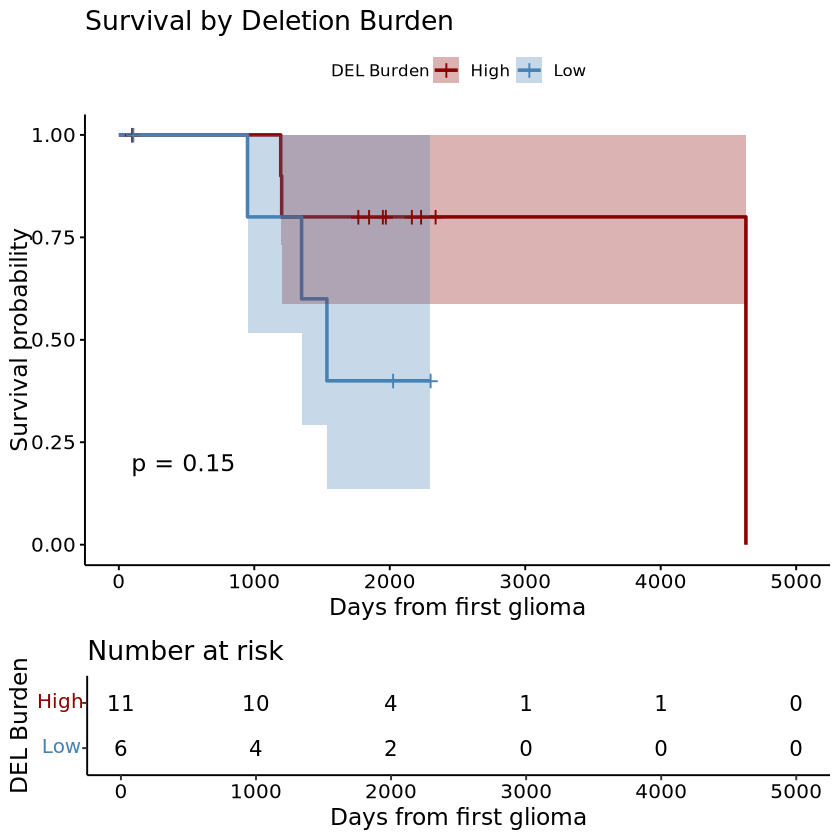

In [100]:
library(survival)
library(survminer)

del_surv_obj <- with(merged, Surv(time_days, status))
km_fit_del <- survfit(del_surv_obj ~ DEL_group, data = merged)

ggsurvplot(km_fit_del,
           data = merged,
           risk.table = TRUE,
           pval = TRUE,
           conf.int = TRUE,
           xlab = "Days from first glioma",
           ylab = "Survival probability",
           title = "Survival by Deletion Burden",
           legend.title = "DEL Burden",
           legend.labs = c("High", "Low"),
           palette = c("darkred", "steelblue"))


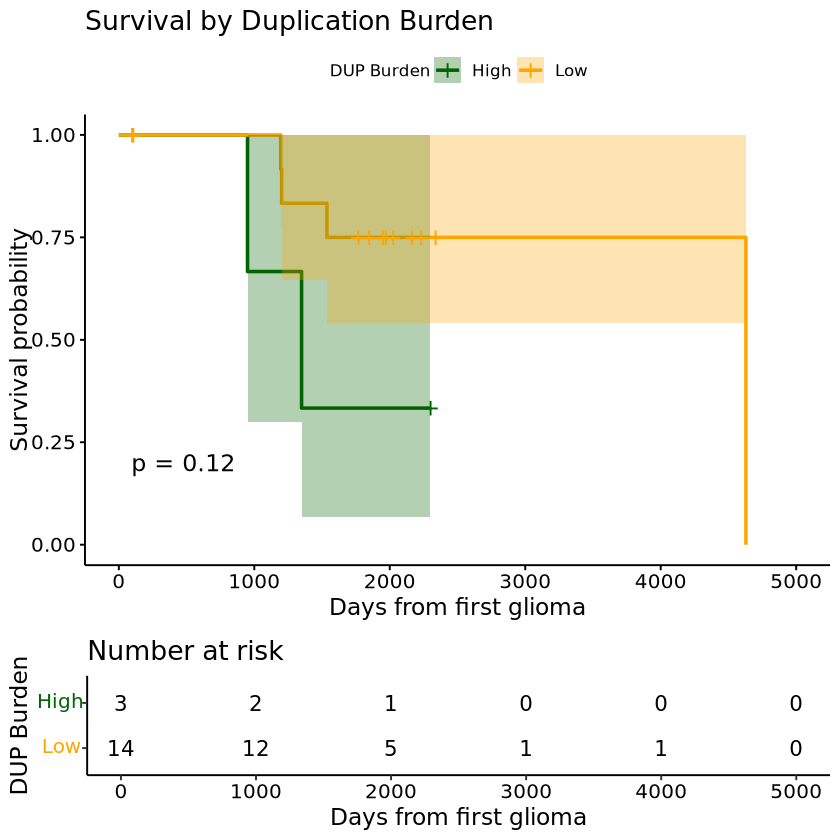

In [101]:
dup_surv_obj <- with(merged, Surv(time_days, status))
km_fit_dup <- survfit(dup_surv_obj ~ DUP_group, data = merged)

ggsurvplot(km_fit_dup,
           data = merged,
           risk.table = TRUE,
           pval = TRUE,
           conf.int = TRUE,
           xlab = "Days from first glioma",
           ylab = "Survival probability",
           title = "Survival by Duplication Burden",
           legend.title = "DUP Burden",
           legend.labs = c("High", "Low"),
           palette = c("darkgreen", "orange"))


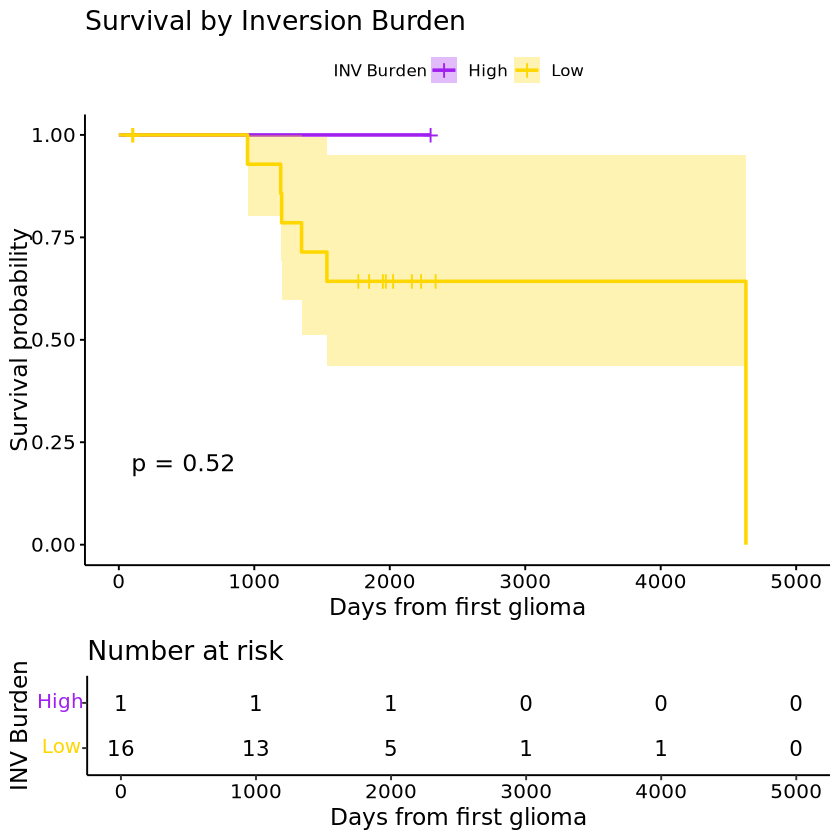

In [102]:
inv_surv_obj <- with(merged, Surv(time_days, status))
km_fit_inv <- survfit(inv_surv_obj ~ INV_group, data = merged)

ggsurvplot(km_fit_inv,
           data = merged,
           risk.table = TRUE,
           pval = TRUE,
           conf.int = TRUE,
           xlab = "Days from first glioma",
           ylab = "Survival probability",
           title = "Survival by Inversion Burden",
           legend.title = "INV Burden",
           legend.labs = c("High", "Low"),
           palette = c("purple", "gold"))


In [114]:
All_sv_counts <- sv_summary %>%
  group_by(Sample_ID) %>%
  summarise(total_sv_count = sum(sv_count), .groups = "drop")

head(All_sv_counts)


Sample_ID,total_sv_count
<chr>,<int>
2436A,30491
3188,20835
3988,29689
6265D,22284
6266D,31527
6269C,24049


In [116]:
merged_df_1 <- left_join(survival_df, sv_count, by = "Sample_ID")


ERROR: Error: object 'sv_count' not found


In [113]:
head(merged_df_1)

,Patient_ID,status,time_days,telomere_group,Sample_ID,DEL,DUP,INS,INV
,<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>
1,2436A,1,4629,normal,2436A,16084,16,14371,20
2,3188,1,1349,short,3188,11280,113,8962,480
3,3988,1,1536,normal,3988,13739,37,15833,80
4,6265D,1,950,normal,6265D,12424,74,9639,147
5,6266D,1,1195,normal,6266D,16703,13,14780,31
6,6269C,0,2300,short,6269C,12487,84,10243,1235


In [110]:
library(dplyr)
library(survival)
library(survminer)

# Step 1: Calculate median of total SVs
median_sv <- median(merged_df_1$total_sv)

# Step 2: Create a new column classifying samples into high or low SV groups
merged_df_1 <- merged_df_1 %>%
  mutate(SV_burden_group = ifelse(total_sv > median_sv, "High SV", "Low SV"))

# Step 3: Create survival object
surv_obj <- Surv(time = sv_data$time_days, event = sv_data$status)

# Step 4: Fit survival model
fit <- survfit(surv_obj ~ SV_burden_group, data = sv_data)

# Step 5: Plot
ggsurvplot(
  fit,
  data = sv_data,
  pval = TRUE,
  risk.table = TRUE,
  title = "Survival Plot Based on SV Burden",
  legend.title = "SV Burden",
  legend.labs = c("High SV", "Low SV"),
  palette = c("red", "blue")
)


ERROR: [1m[33mError[39m in `mutate()`:[22m
[1m[22m[36mℹ[39m In argument: `SV_burden_group = ifelse(total_sv > median_sv, "High
  SV", "Low SV")`.
[1mCaused by error:[22m
[33m![39m object 'total_sv' not found
